In [1]:
%load_ext autoreload
%autoreload 2
from utils_dir import get_curr_dir, include_home_dir
include_home_dir()
import torch
import pandas as pd

from jumpmodels.utils import filter_date_range        # useful helpers
from jumpmodels.jump import JumpModel                 # class of JM & CJM
from jumpmodels.sparse_jump import SparseJumpModel    # class of Sparse JM

# Load Data & Features

This example demonstrates the class of *statistical jump models* (JMs) and various helper functions for regime analysis provided by our package `jumpmodels`, using an application on the Nasdaq-100 Index. 
The core classes, `JumpModel` and `SparseJumpModel`, implement the original JM, continuous JM (CJM), and sparse JM (SJM) with feature selection.
These models follow the API style used in `scikit-learn` for easy integration and efficient usage.
For detailed mathematical and algorithmic explanations of these models, please refer to the literature cited in the `README`.

Relevant helper functions will be imported as needed throughout this example.
If running this notebook in Jupyter Lab/Notebook poses any issues, there is an exported `.py` script available in this folder for convenient execution.


## Raw Data

In this example, we analyze the regimes of the Nasdaq-100 Index.
The daily index price data is retrieved from [Yahoo Finance](https://finance.yahoo.com/quote/%5ENDX/) under the ticker `NDX`. 

The data retrieval is handled in the script `get_data.py`, and the dataset is already saved in the `example/Nasdaq/data/` folder in both `csv` and `pkl` formats, so there’s no need to run `get_data.py` manually.

We work with daily frequency data using `pandas` DataFrames, where the index is of type `datetime.date`. 
This format is consistent with the convention used in the `CRSP` database. 
All helper functions in this package are designed to support this type of date index.

In [2]:
%run get_bitcoin_data.py

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ETH-USD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Successfully downloaded data for ticker: ETH-USD


## Feature Engineering

Feeding the model a robust feature set is key to the successful application of any learning algorithm. 
This example uses a simple feature set consisting of nine features: the exponentially weighted moving (EWM) return, downside deviation (in log scale), and Sortino ratio, each computed with three halflife values ranging from one week (5 days) to one quarter (3 months). 

Users may need to adjust the features or halflives to suit their specific applications. 
The literature referenced in the `README` offers a solid foundation for further exploration.

The computation of these features is detailed in `feature.py` in the same folder as this example, and we use the `DataLoader` class to load both the index returns and the engineered features.
The loaded data covers the period from the start of 2007 to the end of September 2024.

In [3]:
from feature import DataLoader

data = DataLoader(ticker="NDX", ver="v0").load(start_date="2007-1-1", end_date="2024-09-30")

# print("Daily returns stored in `data.ret_ser`:", "-"*50, sep="\n")
# print(data.ret_ser, "-"*50, sep="\n")
# print("Features stored in `data.X`:", "-"*50, sep="\n")
# print(data.X)

## Train/Test Split and Preprocessing

We perform a simple time-based split: data from the beginning of 2007 to the end of 2021, covering a 15-year period, is used as the training set for fitting the JMs.
The period from 2022 to late 2024 is reserved as the test set, where we apply the trained JMs to perform online regime inference.
We use the helper function `filter_date_range` to filter the start and end dates of a DataFrame.

In [4]:
train_start, test_start = "2007-1-1", "2022-1-1"
# filter dates
X_train = filter_date_range(data.ret_ser, start_date=train_start, end_date=test_start)
X_test = filter_date_range(data.ret_ser, start_date=test_start)
# print time split
train_start, train_end = X_train.index[[0, -1]]
test_start, test_end = X_test.index[[0, -1]]
print("Training starts at:", train_start, "and ends at:", train_end)
print("Testing starts at:", test_start, "and ends at:", test_end)

Training starts at: 2007-01-03 and ends at: 2021-12-31
Testing starts at: 2022-01-03 and ends at: 2024-09-27


The module `jumpmodels.preprocess` provides two classes for preprocessing: one for standardizing and one for clipping the feature data. 
We first clip the data within three standard deviations for all features and then perform standardization before feeding the data into the JMs. 
Both classes are first fitted on the training data and subsequently used to transform the test data.

These classes support both `pandas` DataFrames and `numpy` arrays as direct inputs and outputs. 
We prefer to retain the DataFrame type whenever possible to preserve the date index and column labels.

In [5]:
# Suppose X_train and X_test are pandas Series
if isinstance(X_train, pd.Series):
    X_train = pd.DataFrame(X_train.values.reshape(-1, 1), index=X_train.index)
if isinstance(X_test, pd.Series):
    X_test = pd.DataFrame(X_test.values.reshape(-1, 1), index=X_test.index)

In [6]:
X_train

,0
date,
2007-01-03,0.001406
2007-01-04,0.019064
2007-01-05,-0.004244
2007-01-08,0.001031
2007-01-09,0.004751
...,...
2021-12-27,0.015899
2021-12-28,-0.004759
2021-12-29,0.000142


In [7]:
# Preprocessing
from jumpmodels.preprocess import StandardScalerPD, DataClipperStd
clipper = DataClipperStd(mul=3.)
scalar = StandardScalerPD()
# fit on training data
X_train_processed = scalar.fit_transform(clipper.fit_transform(X_train))
# transform the test data
X_test_processed = scalar.transform(clipper.transform(X_test))

In [8]:
X_train_processed[99:].shape

(3678, 1)

<Axes: xlabel='date'>

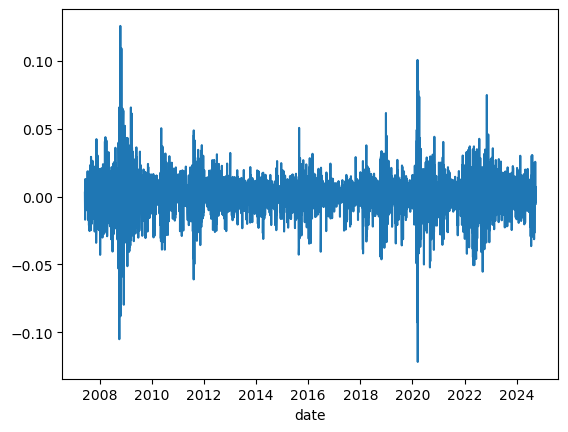

In [9]:
data.ret_ser[104:].plot()

In [10]:
def cum_sum(x: pd.DataFrame, dim: int) -> pd.DataFrame:
    dim = dim # what is the appropriate dim, depends if we use batch or not without its dim 0 with its dim 1
    return x.cumsum(axis=dim)

def lead_lag_transform(x: torch.Tensor) -> torch.Tensor:
    """
    Lead-lag transformation for a multivariate path (two-dimensional tensor).
    """
    # Repeat each sample twice: dim(samplesize, fetures) -> dim(2*samplesize, features) 
    x_rep = torch.repeat_interleave(x, repeats=2, dim=0)
    
    # Interleave repeated values to produce lead-lag transformation
    lead = x_rep[1:, :]
    lag = x_rep[:-1, :]
    x_ll = torch.cat((lead, lag), dim=1)
    
    return x_ll
X_test_processed_cs = cum_sum(X_train_processed,dim=0)
X_test_processed_cs_ll = pd.DataFrame(lead_lag_transform(torch.tensor(X_test_processed_cs.values, dtype=torch.float32)))

In [11]:
# def lead_lag_transform_df(df: pd.DataFrame) -> pd.DataFrame:
#     """
#     Lead-lag transformation for a pandas DataFrame.
#     Each column in the DataFrame represents a feature.
#     """
#     # Repeat each column twice, producing a DataFrame twice as wide
#     df_rep = pd.concat([df] * 2, axis=1, ignore_index=True)
    
#     # Interleave repeated columns to produce lead-lag transformation
#     lead = df_rep.iloc[:, 1:]
#     lag = df_rep.iloc[:, :-1]
    
#     # Combine lead and lag columns along the second axis
#     df_ll = pd.concat([lead, lag], axis=1, ignore_index=True)
    
#     return df_ll

# X_test_processed_ll = lead_lag_transform_df(X_test_processed_cs)

In [12]:
X_test_processed_cs_ll

,0,1
0,5.569790e-02,5.569790e-02
1,1.482375e+00,5.569790e-02
2,1.482375e+00,1.482375e+00
3,1.099370e+00,1.482375e+00
4,1.099370e+00,1.099370e+00
...,...,...
7548,9.136028e-01,9.136028e-01
7549,5.686666e-01,9.136028e-01
7550,5.686666e-01,5.686666e-01
7551,-1.306732e-13,5.686666e-01


### Path Signature Features

##### Exp weigh the data points #####

In [13]:
# #################################### OUTDATED ####################################
# # Calculate exponential weights
# def exp_weighting(length, halflife=10):
#     alpha = 1 - 0.5**(1/halflife)  # equivalent alpha derived from halflife
#     weights = np.exp(-alpha * np.arange(length))[::-1]
#     weighted_ret_ser = data.ret_ser[:length] * weights
#     return weighted_ret_ser

# # calculate exponential weights for all data

# # Create an empty DataFrame with the same index as the original series
# result_df = pd.DataFrame(index=data.ret_ser.index)

# # Generate each series with the corresponding length
# for length in range(20, len(data.ret_ser) + 1):
#     weighted_series = exp_weighting(length)
#     # Pad the remaining values with zeros
#     padded_series = pd.Series(np.zeros(len(data.ret_ser)), index=data.ret_ser.index)
#     padded_series.iloc[:length] = weighted_series
#     result_df[f'length_{length}'] = padded_series
# # Transpose 
# result_df = result_df.T
# # Normalize each row to be between 0 and 1
# result_df = result_df.div(result_df.max(axis=1), axis=0)

# import esig
# import numpy as np

# # List to store the signature features for each row
# all_sig_features = []
# counter = 20
# # Iterate over rows of the dataframe
# for _, row in result_df.iterrows():
#     # Convert the row to a numpy array (reshape if needed)
#     path = row.to_numpy()[:counter]
#     # Compute the signature features for this path
#     sig_features = esig.stream2sig(path.reshape(-1, 1), 3)  # Adjust the order if necessary
#     all_sig_features.append(sig_features)
#     counter +=1
# # If desired, convert the list of features into a DataFrame or another structure
# sig_features_df = pd.DataFrame(all_sig_features)
# ########################################################################

##### Signature on the Returns

In [14]:
import numpy as np
import pandas as pd
import esig

window_size = 30 # Length of the WIndow
order = 4  # Signature truncation order

signatures = []
n = len(X_train_processed)

# Iterate through rolling windows
for start in range(n - window_size + 1):
    # Extract the current window by simple slicing.
    window = X_train_processed[start:start + window_size]
    
    # If the window is 1D, reshape it to a 2D array with one column.
    if window.ndim == 1:
        window = window.reshape(-1, 1)

    X_test_processed_cs = cum_sum(window,dim=0)
    X_test_processed_cs_ll = pd.DataFrame(lead_lag_transform(torch.tensor(X_test_processed_cs.values, dtype=torch.float32)))

    sig = esig.stream2sig(X_test_processed_cs_ll, order)
    signatures.append(sig)

# Convert the list of signatures into a DataFrame.
signature_df = pd.DataFrame(signatures)

# Optionally, assign an index corresponding to the last element of each window.
# Since X_train is a NumPy array, we create an index using np.arange.
signature_df.index = X_train_processed[window_size - 1:].index

# Now signature_df contains the computed signatures.
print(signature_df.head())
print(signature_df.shape)

Loaded intel_openmp/libiomp5md.dll from C:\Users\frede\anaconda3\envs\jm-pack-base\Library\bin\libiomp5md.dll
             0         1         2         3         4         5         6         7         8         9   ...         21        22        23         24         25         26        27         28        29        30
date                                                                                                       ...                                                                                                         
2007-02-14  1.0  0.957796  0.957796  0.458687  7.517618 -6.600245  0.458687  0.146443  7.152708 -7.105069  ... -28.130202  2.778584 -2.110384 -21.406456  13.085125  -8.208659  4.348245  11.529800 -5.959462  0.035066
2007-02-15  1.0 -0.161714 -0.161714  0.013076  6.101479 -6.075328  0.013076 -0.000705 -2.593736  4.200776  ... -18.833970  2.698810 -2.295808 -18.194579   9.222160  -8.316375  4.616321   8.616103 -2.998423  0.000028
2007-02-16  1.0  0.086078 

In [15]:
#################################### OUTDATED ####################################
#  import numpy as np
# import pandas as pd
# import esig

# # Example: X_train is a NumPy array (1D or 2D)
# # If it's 1D (shape: (n_samples,)), we'll reshape it later.
# # If it's already 2D, slicing will work as expected.

# window_size = 100
# order = 3  # Signature truncation order
# signatures = []
# n = len(X_train_processed)

# # Iterate through rolling windows
# for start in range(n - window_size + 1):
#     # Extract the current window by simple slicing.
#     window = X_train_processed[start:start + window_size]
    
#     # If the window is 1D, reshape it to a 2D array with one column.
#     if window.ndim == 1:
#         window = window.reshape(-1, 1)
    
    
#     # Compute the signature for this window.
#     sig = esig.stream2sig(window, order)
#     signatures.append(sig)

# # Convert the list of signatures into a DataFrame.
# signature_df = pd.DataFrame(signatures)

# # Optionally, assign an index corresponding to the last element of each window.
# # Since X_train is a NumPy array, we create an index using np.arange.
# signature_df.index = X_test_processed_cs_ll.index[window_size - 1:]

# # Now signature_df contains the computed signatures.
# print(signature_df.head())


### Post-Scale
- This is used for postscaling
- Normal sigaturer has k^n elements log-signature is not as trivial

In [16]:
import math
from sympy import mobius, divisors

###### For Multivariate TS
def num_terms_at_depth(log_or_normal,d, n):
    """
    Compute the number of terms in the log signature at depth n using the given formula.
    
    Args:
    - d: Dimension of the input path.
    - n: Depth level.

    Returns:
    - Number of log signature terms at depth n.
    """
    if log_or_normal == "log":
        result = 0
        for m in divisors(n):
            result += mobius(m) * d**(n // m)
        return result // n
    elif log_or_normal == "normal":
        return d ** n
    else:
        raise ValueError("Invalid input for log_or_normal. Must be 'log' or 'normal'.")

# Function to rescale signature terms by the factorial of the depth level
def rescale_signature_by_factorial(log_or_normal,signature, dimension, depth):
    """
    Multiplies the terms in the signature by the factorial of their respective depth level.
    Args:
    - signature: The signature tensor.
    - dimension: The number of input dimensions.
    - depth: The maximum depth of the signature.

    Returns:
    - Rescaled signature (factorial-weighted by depth level).
    """
    rescaled_signature = []
    current_index = 0

    for d in range(1, depth + 1):
        # Calculate the number of terms at this depth level
        n_terms_at_depth_d = num_terms_at_depth(log_or_normal,dimension, d)
        # print(n_terms_at_depth_d)
        # print(dimension,d)
        # Compute factorial of the current depth level
        depth_factorial = math.factorial(d)

        # Extract the terms for the current depth and multiply by the depth factorial
        terms_at_depth_d = signature[..., current_index:current_index + n_terms_at_depth_d] * depth_factorial

        # Append the rescaled terms to the rescaled_signature list
        rescaled_signature.append(terms_at_depth_d)

        # Update the index to point to the next depth section
        current_index += n_terms_at_depth_d

    # Concatenate rescaled terms along the feature dimension
    # return torch.cat(rescaled_signature, dim=-1)
    return np.concatenate(rescaled_signature, axis=-1)

In [17]:
signature_df.shape

(3748, 31)

In [18]:
rescaled_sig_df = rescale_signature_by_factorial("normal",signature_df.to_numpy(),31,4)
rescaled_sig_df = pd.DataFrame(rescaled_sig_df)
rescaled_sig_df.index = signature_df.index
rescaled_sig_df

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2007-02-14,1.0,0.957796,0.957796,0.458687,7.517618,-6.600245,0.458687,0.146443,7.152708,-7.105069,...,-28.130202,2.778584,-2.110384,-21.406456,13.085125,-8.208659,4.348245,11.529800,-5.959462,0.035066
2007-02-15,1.0,-0.161714,-0.161714,0.013076,6.101479,-6.075328,0.013076,-0.000705,-2.593736,4.200776,...,-18.833970,2.698810,-2.295808,-18.194579,9.222160,-8.316375,4.616321,8.616103,-2.998423,0.000028
2007-02-16,1.0,0.086078,0.086078,0.003705,6.027903,-6.020493,0.003705,0.000106,-0.269202,1.057276,...,-18.120526,2.569134,-2.133659,-18.190978,10.128318,-7.660122,3.997426,7.635174,-2.544177,0.000002
2007-02-20,1.0,0.526939,0.526939,0.138833,6.271921,-5.994255,0.138833,0.024385,-0.364397,4.033717,...,-17.864647,3.493050,-3.158752,-19.860509,9.750222,-8.675302,4.107663,7.742203,-2.547101,0.003212
2007-02-21,1.0,0.387587,0.387587,0.075112,6.173959,-6.023736,0.075112,0.009704,-2.303058,6.999060,...,-17.330135,4.175221,-3.887263,-19.951520,6.919357,-10.796911,5.611670,9.531896,-2.906445,0.000940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.435189,0.435189,0.094695,18.961397,-18.772008,0.094695,0.013737,-22.656969,53.565720,...,-165.926697,38.594736,-36.236065,-189.627334,61.981048,-101.943626,57.106543,89.898583,-26.543716,0.001495
2021-12-28,1.0,0.117330,0.117330,0.006883,18.957500,-18.943734,0.006883,0.000269,-20.665178,43.554650,...,-176.902647,26.839689,-24.865602,-182.118058,89.968869,-77.728312,44.731825,75.068045,-24.179391,0.000008
2021-12-29,1.0,-0.450230,-0.450230,0.101353,18.914967,-18.712261,0.101353,-0.015211,-30.609164,52.702251,...,-189.234432,25.848369,-23.904335,-165.106842,64.213668,-87.891546,55.430340,100.155080,-38.105055,0.001712


## In-Sample Fitting

We begin by illustrating the in-sample training of the original JM.
The model parameters are set as follows: the number of components/states/regimes is 2, the jump penalty $\lambda$ is 50.0, and `cont=False`, indicating the original discrete JM that performs hard clustering. 
It is important to note that the jump penalty $\lambda$ is a crucial hyperparameter that requires tuning, either through statistical criteria or cross-validation (see references for details). 

The docstring provides comprehensive documentation of all parameters and attributes (thanks to ChatGPT).

In [19]:
rescaled_sig_df

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2007-02-14,1.0,0.957796,0.957796,0.458687,7.517618,-6.600245,0.458687,0.146443,7.152708,-7.105069,...,-28.130202,2.778584,-2.110384,-21.406456,13.085125,-8.208659,4.348245,11.529800,-5.959462,0.035066
2007-02-15,1.0,-0.161714,-0.161714,0.013076,6.101479,-6.075328,0.013076,-0.000705,-2.593736,4.200776,...,-18.833970,2.698810,-2.295808,-18.194579,9.222160,-8.316375,4.616321,8.616103,-2.998423,0.000028
2007-02-16,1.0,0.086078,0.086078,0.003705,6.027903,-6.020493,0.003705,0.000106,-0.269202,1.057276,...,-18.120526,2.569134,-2.133659,-18.190978,10.128318,-7.660122,3.997426,7.635174,-2.544177,0.000002
2007-02-20,1.0,0.526939,0.526939,0.138833,6.271921,-5.994255,0.138833,0.024385,-0.364397,4.033717,...,-17.864647,3.493050,-3.158752,-19.860509,9.750222,-8.675302,4.107663,7.742203,-2.547101,0.003212
2007-02-21,1.0,0.387587,0.387587,0.075112,6.173959,-6.023736,0.075112,0.009704,-2.303058,6.999060,...,-17.330135,4.175221,-3.887263,-19.951520,6.919357,-10.796911,5.611670,9.531896,-2.906445,0.000940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.435189,0.435189,0.094695,18.961397,-18.772008,0.094695,0.013737,-22.656969,53.565720,...,-165.926697,38.594736,-36.236065,-189.627334,61.981048,-101.943626,57.106543,89.898583,-26.543716,0.001495
2021-12-28,1.0,0.117330,0.117330,0.006883,18.957500,-18.943734,0.006883,0.000269,-20.665178,43.554650,...,-176.902647,26.839689,-24.865602,-182.118058,89.968869,-77.728312,44.731825,75.068045,-24.179391,0.000008
2021-12-29,1.0,-0.450230,-0.450230,0.101353,18.914967,-18.712261,0.101353,-0.015211,-30.609164,52.702251,...,-189.234432,25.848369,-23.904335,-165.106842,64.213668,-87.891546,55.430340,100.155080,-38.105055,0.001712


In [20]:
# set the jump penalty
jump_penalty=0.00
# initlalize the JM instance
jm = JumpModel(n_components=2, jump_penalty=jump_penalty, cont=False, )
# call .fit()
jm.fit(rescaled_sig_df.iloc[:,:], data.ret_ser, sort_by="cumret")

JumpModel()

In the `.fit()` call, we pass the return series for each period to be used for sorting the states.
We specify `sort_by="cumret"`, meaning that the state labels (0 or 1) are determined by the cumulative returns under each state. The state with higher cumulative returns is denoted as $s_t=0$ (bull market), and the state with lower returns is denoted as $s_t=1$ (bear market). 


In [21]:
# from minisom import MiniSom

# # Convert sig_features_df to a NumPy array if it’s not already
# data_som = rescaled_sig_df.iloc[:,1:].values

# # Define the size of the SOM grid and other hyperparameters
# som = MiniSom(x=2, y=1, input_len=data_som.shape[1], sigma=2.0, learning_rate=0.001)

# # Initialize the SOM weights
# som.random_weights_init(data_som)

# # Train the SOM
# som.train(data=data_som, num_iteration=20000)

# # Get the SOM labels and indices
# labels = [som.winner(x) for x in data_som]
# label_indices = [y * som._weights.shape[0] + x for x, y in labels]
# label_series = pd.Series(label_indices, index = signature_df.index)
# # filtered_label_series = label_series.rolling(window=6).mean().round() 
# # filtered_label_series = filtered_label_series[20:].astype(int)

### Visualization

The `jumpmodels.plot` module provides useful functions for visualizing regime identification. 
We'll use the `labels_` attribute of the JM instance, which contains integers from 0 to `n_c-1`, representing the in-sample fitted regime assignment for each period.

From the plot, we observe that the identified regimes for the Nasdaq-100 Index successfully capture several significant market downturns, including the global financial crisis, corrections in 2012, 2015-2016, 2019, and the COVID-19 crash in 2020. 
These identified regimes correspond well to shifts in market fundamentals, as interpreted in hindsight.


In [22]:
# label_series

In [23]:
# data.ret_ser

In [24]:

# import sys
# sys.path.insert(0, r"C:\Users\frede\OneDrive\Dokumente\GitHub")
# from SIGSOM.sigsom.som.adapted_som import GSOMM
# from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# from datetime import datetime
# t0 = datetime.now()


# data_som = rescaled_sig_df.iloc[:,:].values
# data_som.shape

# train_matrix1 = torch.tensor(data_som[:,:], dtype=torch.float32)

# params = SOMParams(map_size=(2, 1),batch_size=32,Tmax=3,Tmin=.1,iterations =1000, input_dims=train_matrix1.shape[1], lr=0.01, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))

# gsomm = GSOMM(logger=logger, params=params)
# gsomm.somm.initialize(train_matrix1)


# inital_preds, initial_quant_error = gsomm.initial_train(X_train=train_matrix1)
# t0 = datetime.now()



In [25]:
data_som = rescaled_sig_df.iloc[:,:].values
data_som.shape
train_matrix1 = torch.tensor(data_som[:,:], dtype=torch.float32)
train_matrix1.shape

torch.Size([3748, 31])

In [26]:
import sys
sys.path.insert(0, r"C:\Users\frede\OneDrive\Dokumente\GitHub")
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
from datetime import datetime

t0 = datetime.now()

# Use SOM directly instead of GSOMM
params = SOMParams(map_size=(2, 1), batch_size=512, Tmax=2, Tmin=0.01,
                   iterations=10000, input_dims=train_matrix1.shape[1],
                   lr=0.01, dump_path=r"C:\Your\Dump\Path")
som_model = SOM(logger=logger, params=params)

# Initialize SOM with your training data (e.g., train_matrix1)
som_model.initialize(train_matrix1)

# Now train or use the model as needed:
som_model.fit(X_train=train_matrix1, iterations=params.iterations, batch_size=params.batch_size,
              Tmax=params.Tmax, Tmin=params.Tmin)

# Later, get predictions or quantization errors, etc.
initial_preds = som_model.predict(train_matrix1)
# to numpy sereis and index
initial_preds= initial_preds.numpy()
initial_preds_series = pd.Series(initial_preds, index = signature_df.index)


2025-02-15 16:45:53,318             som INFO     MainThread   MainProcess Save interval: 50
2025-02-15 16:45:56,002             som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-15 16:45:56,003             som INFO     MainThread   MainProcess   [Train] - L = 52148560.0, L_km = 29486292.0
2025-02-15 16:45:56,004             som INFO     MainThread   MainProcess   [Train] - L = 52148560.0, som_loss = 52148560.0


tensor(29486292.)


2025-02-15 16:45:57,347             som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-15 16:45:57,348             som INFO     MainThread   MainProcess   [Train] - L = 53664720.0, L_km = 30529014.0
2025-02-15 16:45:57,349             som INFO     MainThread   MainProcess   [Train] - L = 53664720.0, som_loss = 53664720.0


tensor(30529014.)


2025-02-15 16:45:58,838             som INFO     MainThread   MainProcess Iteration 149 - T=N/A
2025-02-15 16:45:58,839             som INFO     MainThread   MainProcess   [Train] - L = 39804280.0, L_km = 22788342.0
2025-02-15 16:45:58,841             som INFO     MainThread   MainProcess   [Train] - L = 39804280.0, som_loss = 39804280.0


...

tensor(9188329.)


2025-02-15 16:51:53,284             som INFO     MainThread   MainProcess Iteration 9949 - T=N/A
2025-02-15 16:51:53,285             som INFO     MainThread   MainProcess   [Train] - L = 6471917.5, L_km = 6471917.5
2025-02-15 16:51:53,286             som INFO     MainThread   MainProcess   [Train] - L = 6471917.5, som_loss = 6471917.5


tensor(6471917.5000)


2025-02-15 16:51:55,216             som INFO     MainThread   MainProcess Iteration 9999 - T=N/A
2025-02-15 16:51:55,217             som INFO     MainThread   MainProcess   [Train] - L = 11390735.0, L_km = 11390735.0
2025-02-15 16:51:55,218             som INFO     MainThread   MainProcess   [Train] - L = 11390735.0, som_loss = 11390735.0


tensor(11390735.)


In [27]:
filtered_initial_preds_series = initial_preds_series.rolling(window=10).mean().round()
filtered_initial_preds_series = filtered_initial_preds_series[9:].astype(int)


In [28]:
filtered_initial_preds_series

date
2007-02-28    0
2007-03-01    0
2007-03-02    0
2007-03-05    0
2007-03-06    0
             ..
2021-12-27    0
2021-12-28    0
2021-12-29    0
2021-12-30    0
2021-12-31    0
Length: 3739, dtype: int64

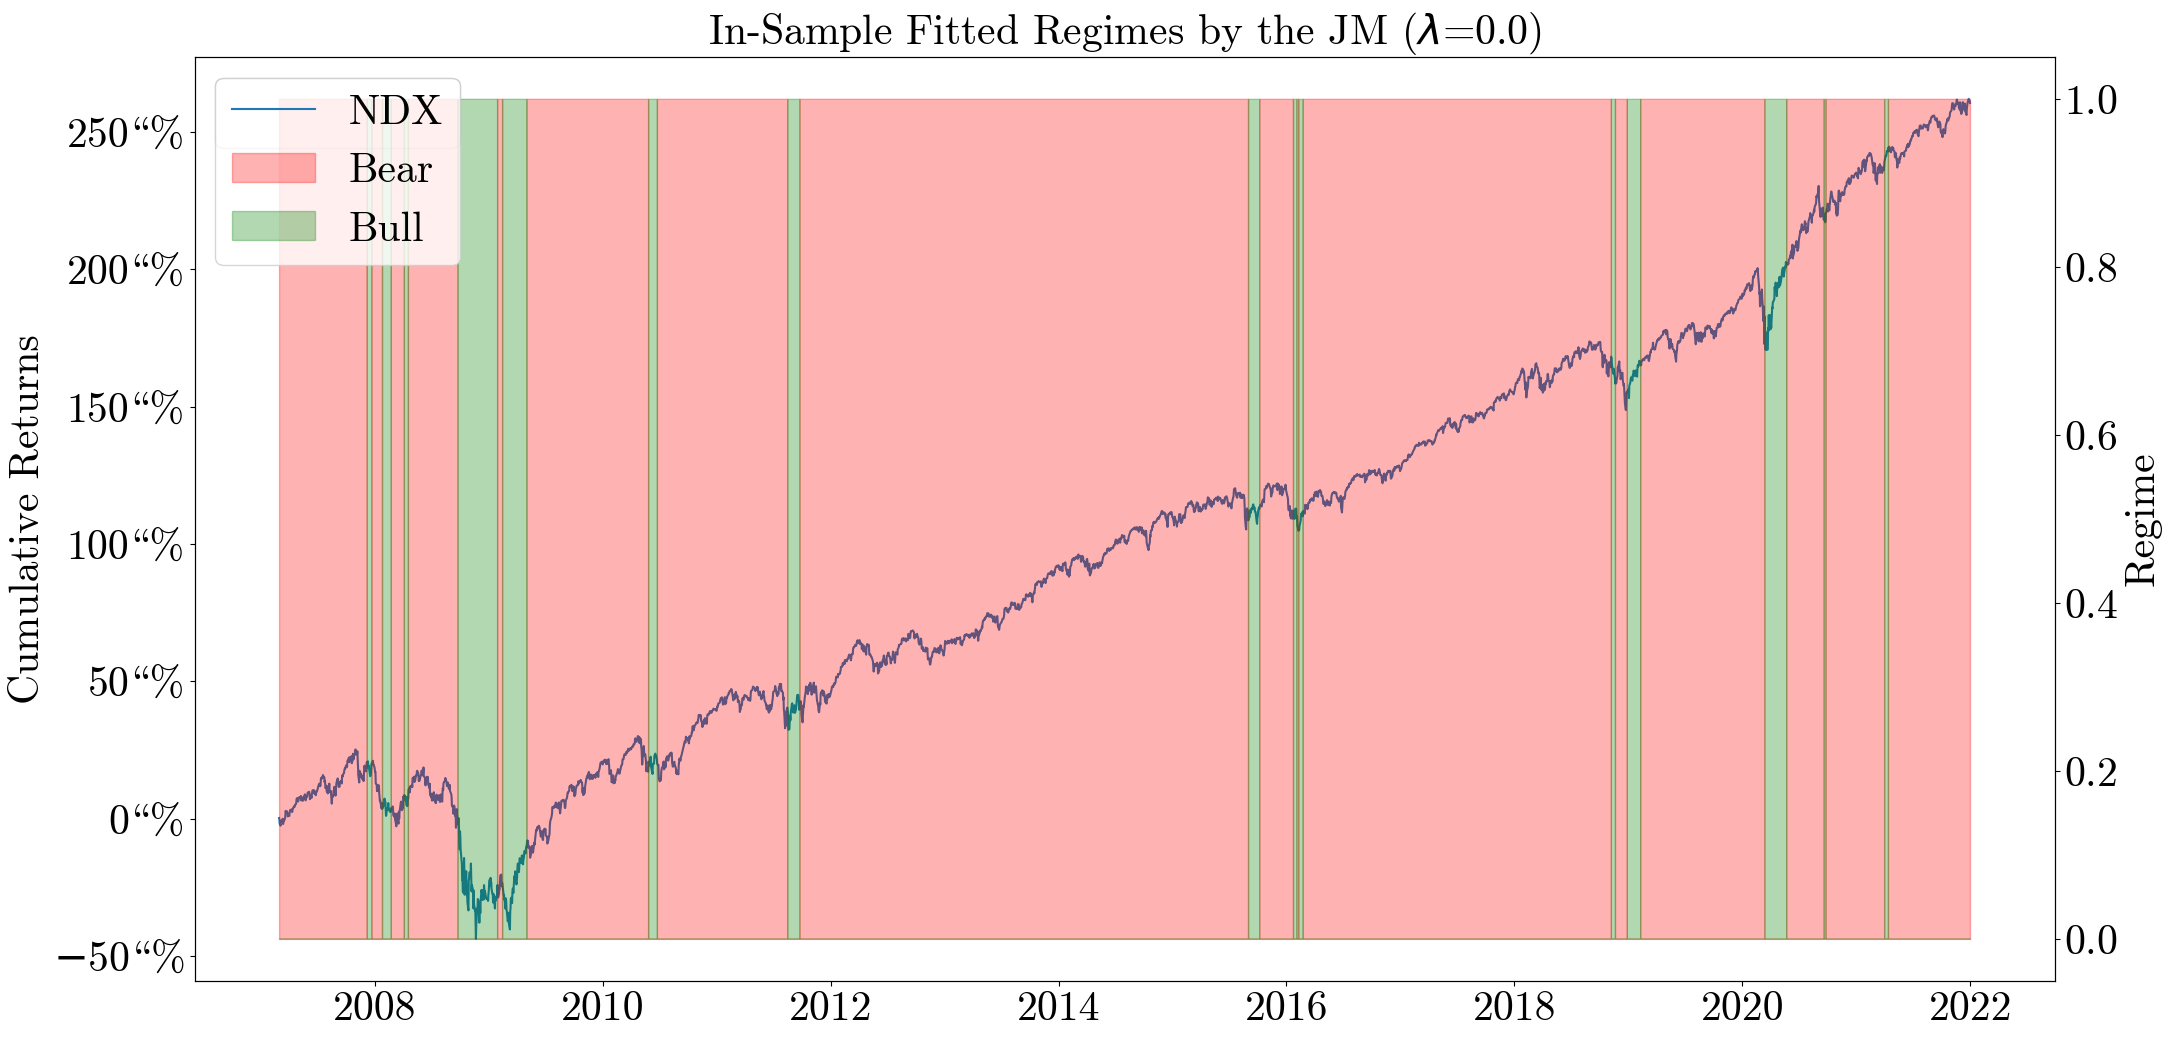

In [29]:
from minisom import MiniSom

# Convert sig_features_df to a NumPy array if it’s not already
data_som = rescaled_sig_df.iloc[:,:].values

# Define the size of the SOM grid and other hyperparameters
som = MiniSom(x=2, y=1, input_len=data_som.shape[1], sigma=1.1, learning_rate=0.008)

# Initialize the SOM weights
som.random_weights_init(data_som)

# Train the SOM
som.train(data=data_som, num_iteration=10000)

# Get the SOM labels and indices
labels = [som.winner(x) for x in data_som]
label_indices = [y * som._weights.shape[0] + x for x, y in labels]
label_series = pd.Series(label_indices, index = signature_df.index)
filtered_label_series = label_series.rolling(window=10).mean().round()
filtered_label_series = filtered_label_series[9:].astype(int)

from jumpmodels.plot import plot_regimes_and_cumret, savefig_plt
import matplotlib as mpl

# Disable external LaTeX rendering, use built-in mathtext:
# Disable external LaTeX rendering, use built-in mathtext:
mpl.rcParams['text.usetex'] = False
ax, ax2 = plot_regimes_and_cumret(filtered_initial_preds_series, data.ret_ser, n_c=2, start_date="2007-02-28" , end_date=train_end, colors_regimes = ['r', 'g'], labels_regimes=['Bear', 'Bull'],)
ax.set(title=f"In-Sample Fitted Regimes by the JM ($\\lambda$={jump_penalty})")
savefig_plt(f"{get_curr_dir()}/plots/JM_lambd-{jump_penalty}_train.pdf")

### Modifying Parameters via `set_params()`

Our model inherits from the `BaseEstimator` class provided by `scikit-learn`, enabling a wide range of utility methods.
Among these, we highlight the `.set_params()` function, which allows users to reset any input parameters without creating a new instance.
This functionality is particularly useful when the model needs to be refitted multiple times, such as when testing different jump penalties.

As an example, we reset the jump penalty to zero, effectively reducing the model to a baseline $k$-means clustering algorithm where temporal information is ignored. 
This comparison illustrates the value of applying a jump penalty to ensure temporal consistency and reduce the occurrence of unrealistic regime shifts.

In [30]:
# # reset jump_penalty to zero
# jump_penalty=0.
# jm.set_params(jump_penalty=jump_penalty)
# print("The jump penalty of the JM instance has been reset to: jm.jump_penalty =", jm.jump_penalty)

# # refit
# jm.fit(X_train_processed["sortino_20"], data.ret_ser, sort_by="cumret")

# # plot
# ax, ax2 = plot_regimes_and_cumret(jm.labels_, data.ret_ser, n_c=2, start_date=train_start, end_date=train_end, )
# ax.set(title=f"In-Sample Fitted Regimes by the JM ($\\lambda$={jump_penalty})")
# savefig_plt(f"{get_curr_dir()}/plots/JM_lambd-{jump_penalty}_train.pdf")

## Online Inference

After completing the in-sample training, we apply the trained models for online inference on the test period using the `predict_online()` method. 
Here, *online inference* means that the regime inference for period $t$ is based solely on the data available up to the end of that period, without using any future data.
We revert the jump penalty to a reasonable value of 50.0.



In [31]:
X_test_processed

,0
date,
2022-01-03,0.810918
2022-01-04,-1.098160
2022-01-05,-2.475981
2022-01-06,-0.085060
2022-01-07,-0.906287
...,...
2024-09-23,0.184704
2024-09-24,0.308860
2024-09-25,0.054646


In [32]:
import numpy as np
import pandas as pd
import esig

window_size = 30
order = 4  # Signature truncation order
signatures = []
n = len(X_test_processed)

# Iterate through rolling windows
for start in range(n - window_size + 1):
    # Extract the current window by simple slicing.
    window = X_test_processed[start:start + window_size]
    
    # If the window is 1D, reshape it to a 2D array with one column.
    if window.ndim == 1:
        window = window.reshape(-1, 1)

    X_test_processed_cs = cum_sum(window,dim=0)
    X_test_processed_cs_ll = pd.DataFrame(lead_lag_transform(torch.tensor(X_test_processed_cs.values, dtype=torch.float32)))

    sig = esig.stream2sig(X_test_processed_cs_ll, order)
    signatures.append(sig)

# Convert the list of signatures into a DataFrame.
signature_df_test = pd.DataFrame(signatures)

# Optionally, assign an index corresponding to the last element of each window.
signature_df_test.index = X_test_processed[window_size - 1:].index

# Now signature_df contains the computed signatures.
print(signature_df_test.head())
print(signature_df_test.shape)

             0          1          2          3           4          5          6           7           8           9   ...           21           22          23           24          25           26          27           28          29          30
date                                                                                                                    ...                                                                                                                             
2022-02-14  1.0 -12.364128 -12.364128  76.435835  110.217109  42.654561  76.435835 -315.020825 -605.474811 -151.788858  ...  -451.736302  1450.493104  567.436313  1412.262740  372.512748  1270.689918  268.596522  1531.677586 -357.902699  973.739477
2022-02-15  1.0  -9.402786  -9.402786  44.206195   79.120217   9.292173  44.206195 -138.553800 -409.529921   75.109356  ... -1183.238346   571.327065  126.086830   720.717962 -389.597183   232.784814  216.384709  1318.052885 -819.372998  325.697941
2022

In [33]:
signature_df_test

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2022-02-14,1.0,-12.364128,-12.364128,76.435835,110.217109,42.654561,76.435835,-315.020825,-605.474811,-151.788858,...,-451.736302,1450.493104,567.436313,1412.262740,372.512748,1270.689918,268.596522,1531.677586,-357.902699,973.739477
2022-02-15,1.0,-9.402786,-9.402786,44.206195,79.120217,9.292173,44.206195,-138.553800,-409.529921,75.109356,...,-1183.238346,571.327065,126.086830,720.717962,-389.597183,232.784814,216.384709,1318.052885,-819.372998,325.697941
2022-02-16,1.0,-7.071496,-7.071496,25.003028,56.862276,-6.856220,25.003028,-58.936271,-246.069284,90.037213,...,-868.911357,242.978583,-7.981428,123.418767,-118.938094,18.812090,71.220984,655.169137,-500.192206,104.191901
2022-02-17,1.0,-9.336124,-9.336124,43.581610,78.197760,8.965461,43.581610,-135.627780,-343.661369,-42.741281,...,-615.280868,656.921654,25.663596,151.020518,325.321940,471.398978,-142.566098,494.421368,-356.504164,316.559459
2022-02-18,1.0,-9.371927,-9.371927,43.916506,78.565744,9.267268,43.916506,-137.194094,-317.999174,-100.314053,...,-350.231335,775.480369,-74.099366,-106.023062,429.326536,409.615607,-193.192702,304.660647,-203.983616,321.443251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-23,1.0,3.966159,3.966159,7.865208,24.351525,-8.621108,7.865208,10.398222,43.838603,8.904809,...,-129.148606,59.566799,-41.376444,-122.627509,77.563594,-11.350632,-20.200920,35.530673,-42.505841,10.310250
2024-09-24,1.0,2.383877,2.383877,2.841436,17.587244,-11.904372,2.841436,2.257878,5.756355,30.413122,...,-76.849417,49.155854,-52.693678,-140.933125,23.814089,-69.661409,23.521475,41.828278,-15.940219,1.345626
2024-09-25,1.0,2.425598,2.425598,2.941762,17.688978,-11.805454,2.941762,2.378511,5.689984,31.526377,...,-75.035359,50.934497,-54.348488,-142.648367,22.130539,-71.388870,23.776917,42.011017,-15.787334,1.442327


In [34]:
### Rescale
res_signature_df_test = rescale_signature_by_factorial("normal", signature_df_test.to_numpy(),31,4)
res_signature_df_test = pd.DataFrame(res_signature_df_test)
res_signature_df_test.index = signature_df_test.index
res_signature_df_test

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2022-02-14,1.0,-12.364128,-12.364128,76.435835,110.217109,42.654561,76.435835,-315.020825,-605.474811,-151.788858,...,-451.736302,1450.493104,567.436313,1412.262740,372.512748,1270.689918,268.596522,1531.677586,-357.902699,973.739477
2022-02-15,1.0,-9.402786,-9.402786,44.206195,79.120217,9.292173,44.206195,-138.553800,-409.529921,75.109356,...,-1183.238346,571.327065,126.086830,720.717962,-389.597183,232.784814,216.384709,1318.052885,-819.372998,325.697941
2022-02-16,1.0,-7.071496,-7.071496,25.003028,56.862276,-6.856220,25.003028,-58.936271,-246.069284,90.037213,...,-868.911357,242.978583,-7.981428,123.418767,-118.938094,18.812090,71.220984,655.169137,-500.192206,104.191901
2022-02-17,1.0,-9.336124,-9.336124,43.581610,78.197760,8.965461,43.581610,-135.627780,-343.661369,-42.741281,...,-615.280868,656.921654,25.663596,151.020518,325.321940,471.398978,-142.566098,494.421368,-356.504164,316.559459
2022-02-18,1.0,-9.371927,-9.371927,43.916506,78.565744,9.267268,43.916506,-137.194094,-317.999174,-100.314053,...,-350.231335,775.480369,-74.099366,-106.023062,429.326536,409.615607,-193.192702,304.660647,-203.983616,321.443251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-23,1.0,3.966159,3.966159,7.865208,24.351525,-8.621108,7.865208,10.398222,43.838603,8.904809,...,-129.148606,59.566799,-41.376444,-122.627509,77.563594,-11.350632,-20.200920,35.530673,-42.505841,10.310250
2024-09-24,1.0,2.383877,2.383877,2.841436,17.587244,-11.904372,2.841436,2.257878,5.756355,30.413122,...,-76.849417,49.155854,-52.693678,-140.933125,23.814089,-69.661409,23.521475,41.828278,-15.940219,1.345626
2024-09-25,1.0,2.425598,2.425598,2.941762,17.688978,-11.805454,2.941762,2.378511,5.689984,31.526377,...,-75.035359,50.934497,-54.348488,-142.648367,22.130539,-71.388870,23.776917,42.011017,-15.787334,1.442327


### Predict

In [35]:
# Later, get predictions or quantization errors, etc.
data_som_test = res_signature_df_test.iloc[:,:].values
data_som_test.shape
test_matrix1 = torch.tensor(data_som_test[:,:], dtype=torch.float32)
test_matrix1.shape

initial_preds_test = som_model.predict(test_matrix1)
# to numpy sereis and index
initial_preds_test_series= initial_preds_test.numpy()
initial_preds_test_series = pd.Series(initial_preds_test, index = res_signature_df_test.index)

In [36]:
filtered_initial_preds_series_test = initial_preds_test_series.rolling(window=10).mean().round()
filtered_initial_preds_series_test = filtered_initial_preds_series_test[9:].astype(int)

In [37]:
filtered_initial_preds_series

date
2007-02-28    0
2007-03-01    0
2007-03-02    0
2007-03-05    0
2007-03-06    0
             ..
2021-12-27    0
2021-12-28    0
2021-12-29    0
2021-12-30    0
2021-12-31    0
Length: 3739, dtype: int64

In [38]:
data_som_test = res_signature_df_test.iloc[:,:].values

labels_test_online = [som.winner(x) for x in data_som_test]
label_indices_test = [y * som._weights.shape[0] + x for x, y in labels_test_online]
labels_test_online_series = pd.Series(label_indices_test, index=res_signature_df_test.index)


In [39]:
# refit
jump_penalty=50.
jm.set_params(jump_penalty=jump_penalty).fit(X_train_processed, data.ret_ser, sort_by="cumret")
# make online inference 
labels_test_online = jm.predict_online(X_test_processed)

From the visualization below, we observe that the JM effectively signals the bear market in 2022, driven by aggressive interest rate hikes. 
This period saw a return of over $-$15% and a significant drawdown.
However, the brief bear period captured in the second half of 2024 is followed by a strong price reversal.
This latency issue constitutes a common challenge in real-time applications of regime-switching signals.
Improving the feature set or fine-tuning the jump penalty may help address this issue.

In [40]:
initial_preds_test_series

date
2022-02-14    1
2022-02-15    1
2022-02-16    1
2022-02-17    1
2022-02-18    1
             ..
2024-09-23    0
2024-09-24    0
2024-09-25    0
2024-09-26    0
2024-09-27    0
Length: 659, dtype: int64

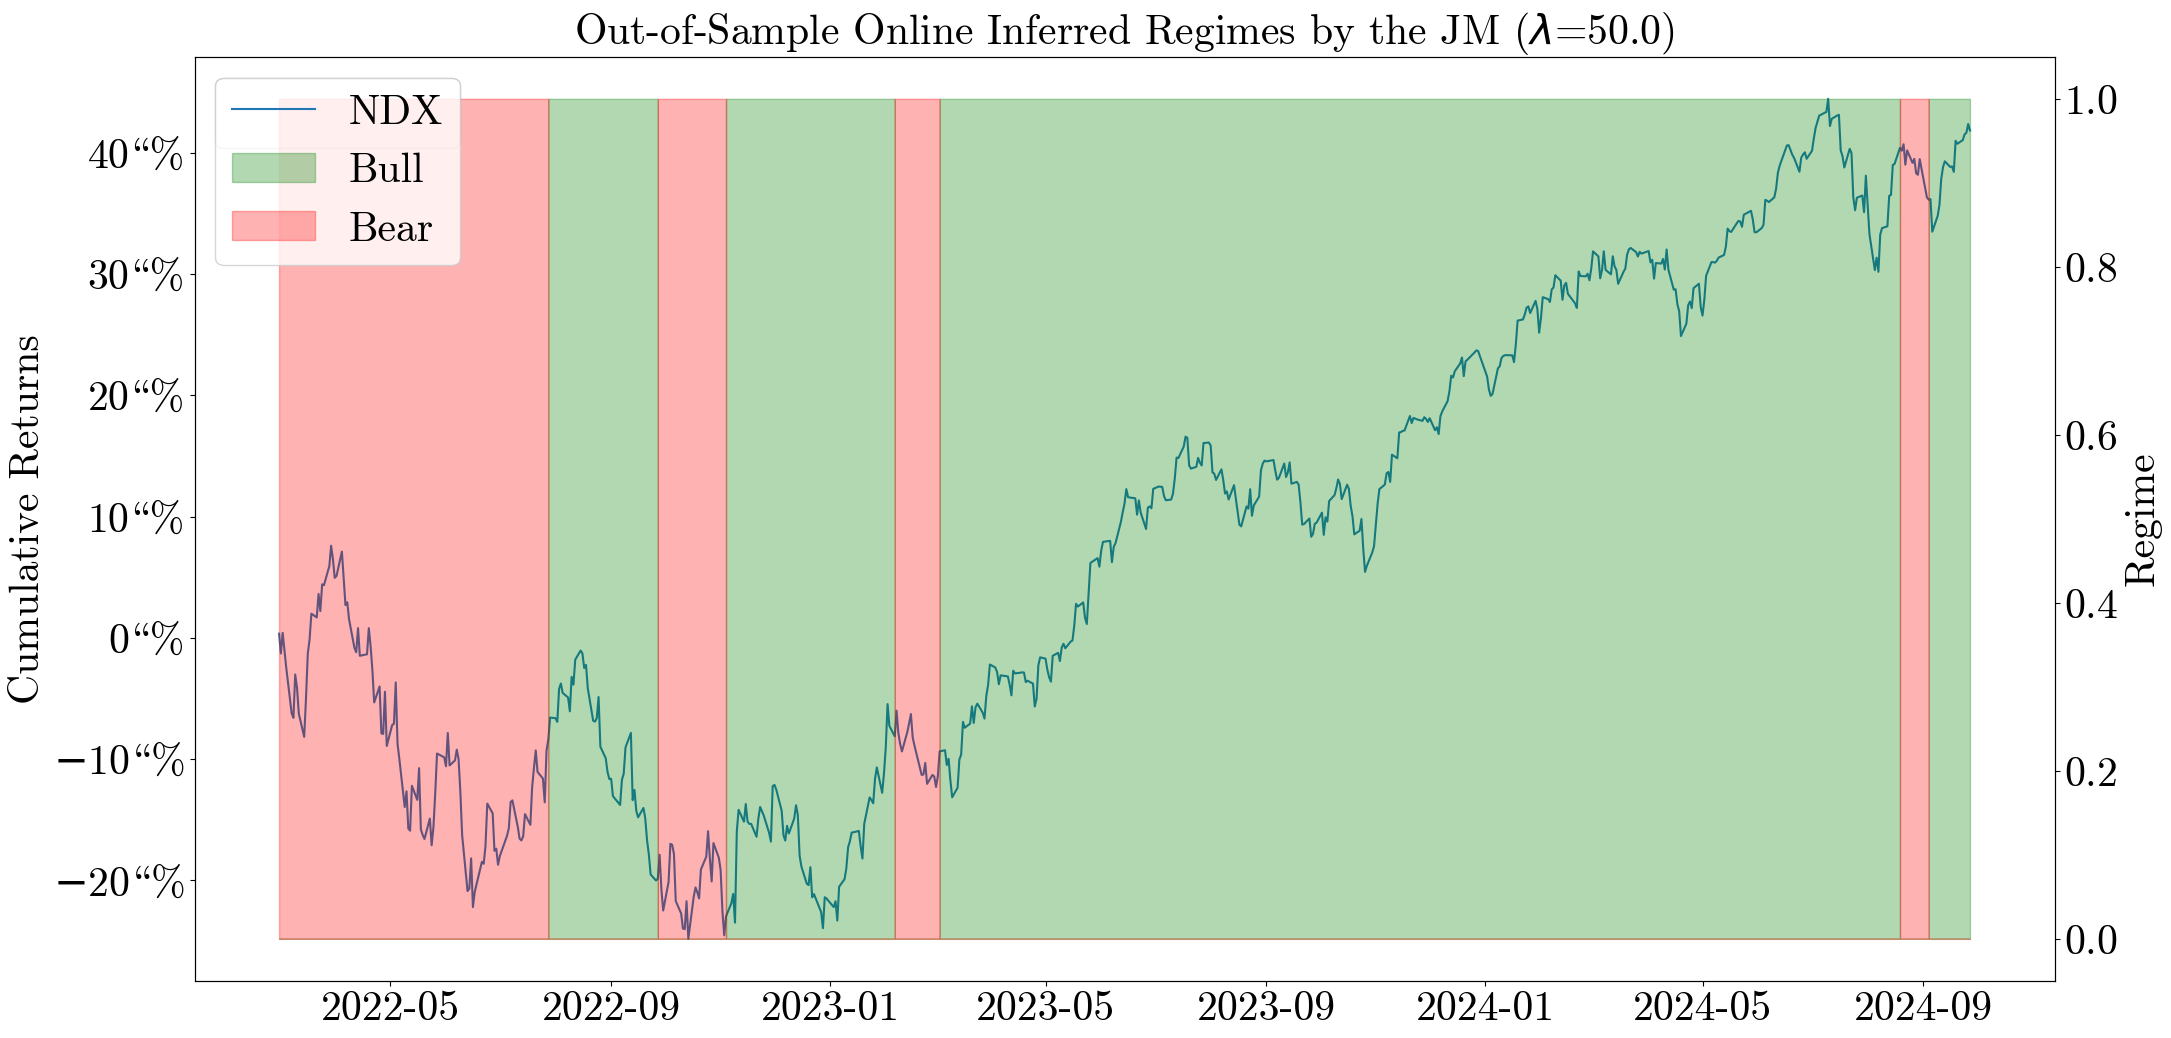

In [41]:
# plot and save
ax, ax2 = plot_regimes_and_cumret(filtered_initial_preds_series_test, data.ret_ser, n_c=2, start_date="2022-02-28 ", end_date=test_end, )
ax.set(title=f"Out-of-Sample Online Inferred Regimes by the JM ($\\lambda$={jump_penalty})")
savefig_plt(f"{get_curr_dir()}/plots/JM_lambd-{jump_penalty}_test_online.pdf")

In contrast to online inference, the `.predict()` method performs state decoding using all test data (i.e., from 2022 to 2024) at once. 
While this approach is less realistic for trading applications, we observe that, with access to the full dataset, the model avoids the reversal in late 2024 and exits the bear signal in 2023 slightly earlier than with online inference.

Though this approach is less applicable for real-world backtesting in financial markets, it holds potential uses in other engineering fields (such as language modeling, where access to an entire sentence is available at once.)

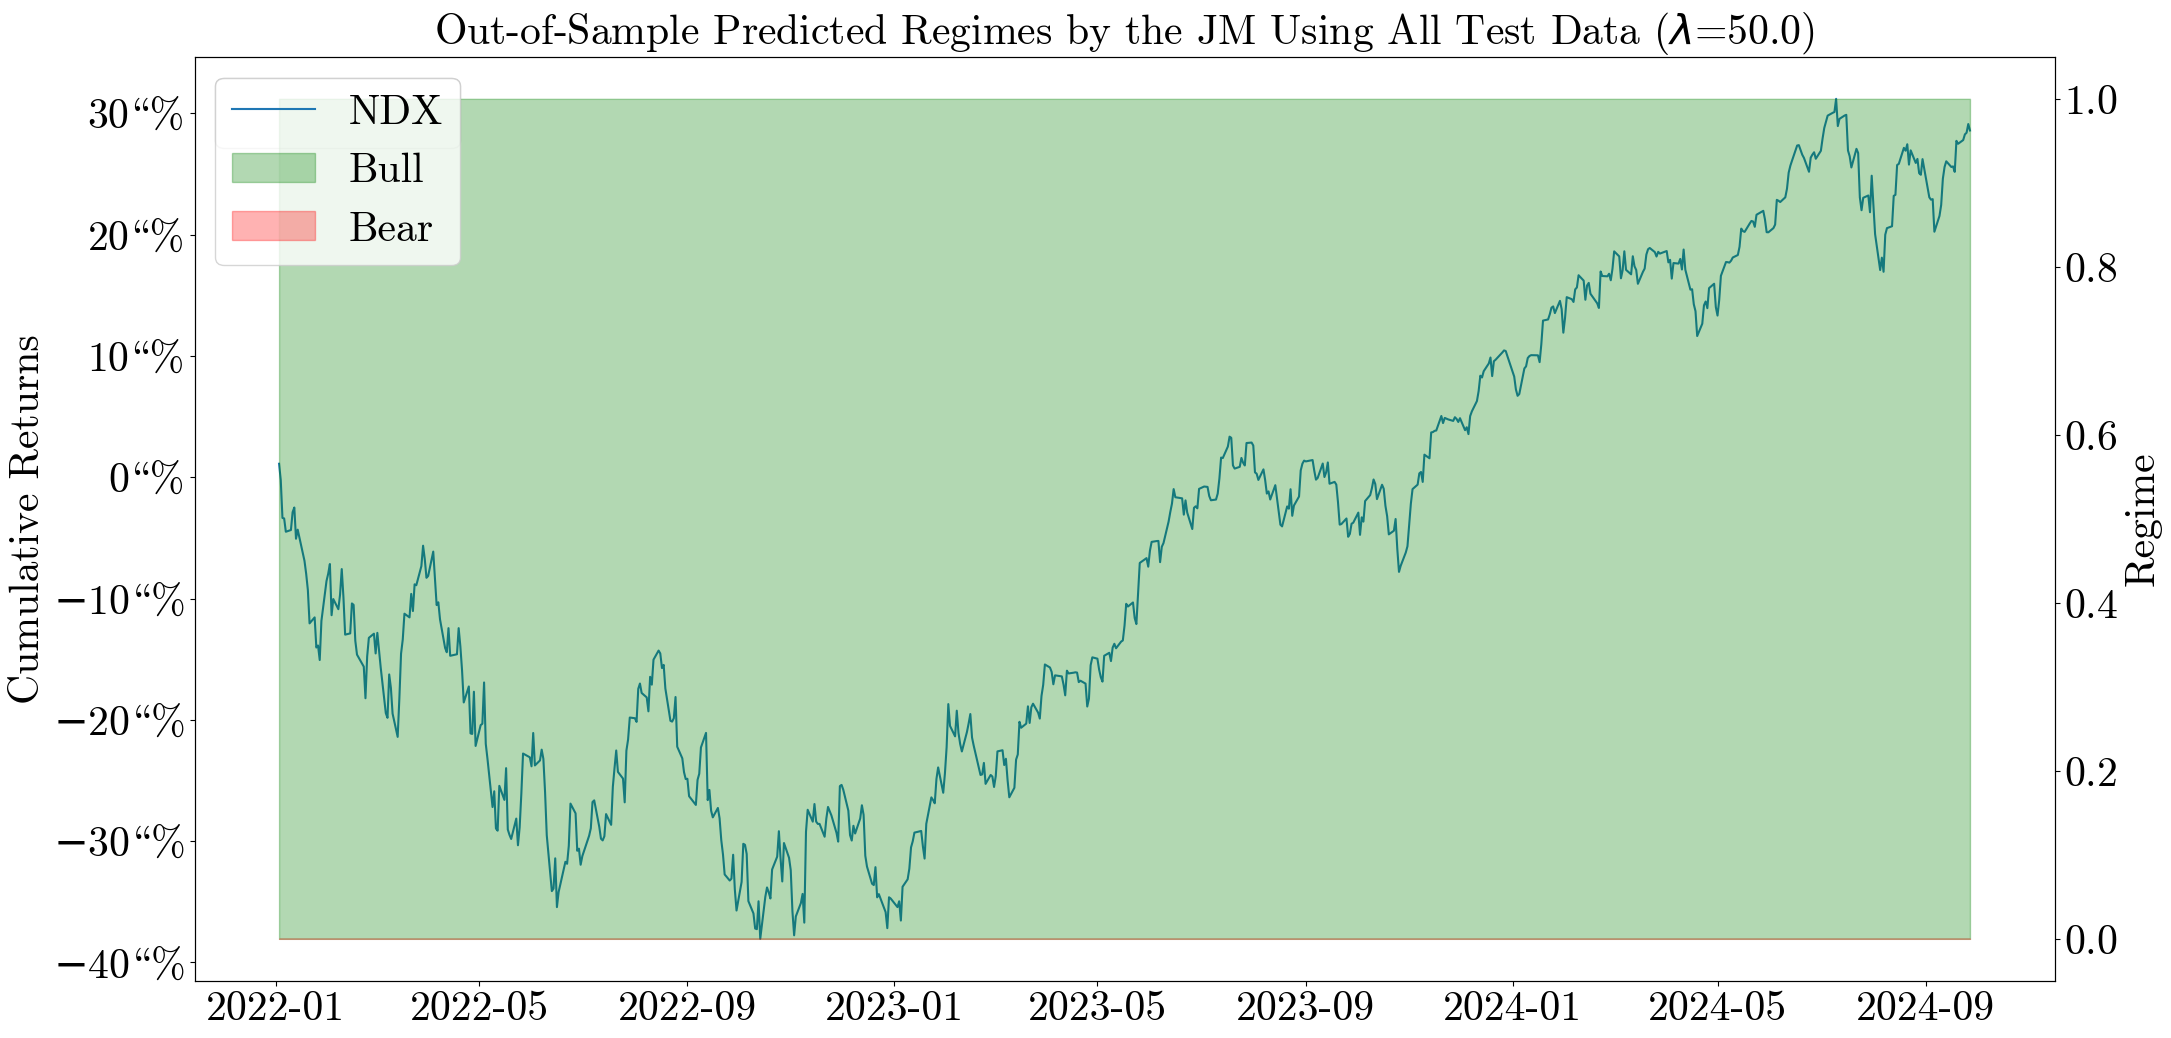

In [42]:
# make inference using all test data
labels_test = jm.predict(X_test_processed)
# plot
ax, ax2 = plot_regimes_and_cumret(labels_test, data.ret_ser, n_c=2, start_date=test_start, end_date=test_end, )
_ = ax.set(title=f"Out-of-Sample Predicted Regimes by the JM Using All Test Data ($\\lambda$={jump_penalty})")

# CJM: Continuous Extension of the JM

With this, we conclude a minimal overview of the core functionality of using JMs to assign regime labels to in-sample training periods and leverage trained models for out-of-sample prediction, either through online inference or by processing all data at once. 
The methods -- such as `.fit()`, `.set_params()`, and `predict_online()` -- extend seamlessly to the following JM variants: CJM and SJM. 
Here, we provide brief illustrations of these extensions.

## In-Sample Fitting

The CJM (Continuous Jump Model) uses the same `JumpModel` class as the discrete model, with the parameter `cont=True`. 

### Parameters 

Regarding the jump penalty value, it is typically set to be 10 times larger than the $\lambda$ used in the discrete model to achieve similar fittings, so we choose $\lambda=600.0$ here.

Additionally, CJM introduces two specialized parameters: `mode_loss` and `grid_size`, which require more nuanced understanding. 
Generally, the default values are recommended for most cases.


In [43]:
jump_penalty=600.
cjm = JumpModel(n_components=2, jump_penalty=jump_penalty, cont=True)

The `proba_` attribute of the CJM instance stores the estimated probability of each period belonging to each state.
Unlike the discrete model, where the state assignment changes abruptly, CJM offers smooth probability transitions, ranging from 0% to 100%. 
This probabilistic interpretation has potential applications in many domains, especially where softer regime assignments are beneficial.

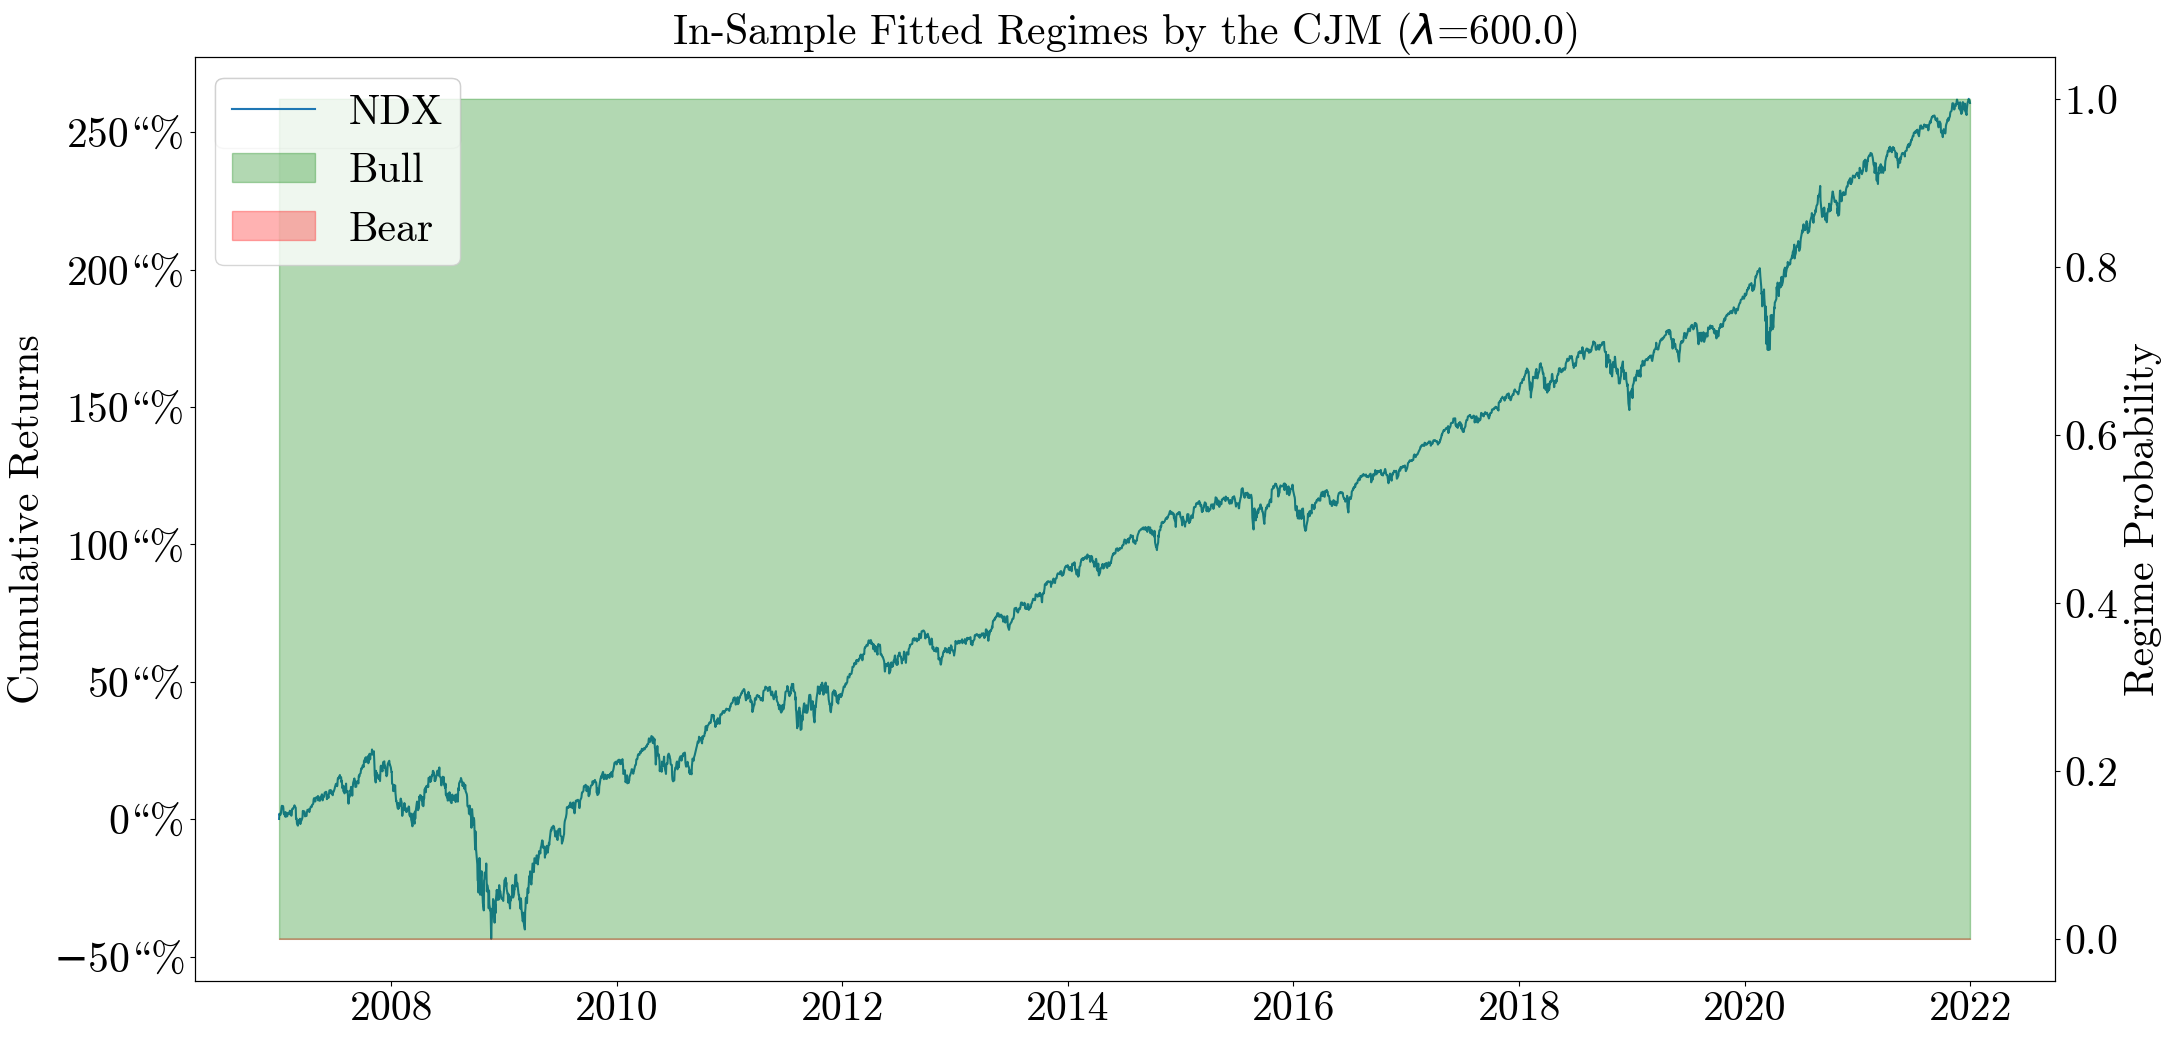

In [44]:
cjm.fit(X_train_processed, data.ret_ser, sort_by="cumret")

# plot
ax, ax2 = plot_regimes_and_cumret(cjm.proba_, data.ret_ser, n_c=2, start_date=train_start, end_date=train_end, )
ax2.set(ylabel="Regime Probability")
ax.set(title=f"In-Sample Fitted Regimes by the CJM ($\\lambda$={jump_penalty})")
savefig_plt(f"{get_curr_dir()}/plots/CJM_lambd-{jump_penalty}_train.pdf")

## Online Inference

The `.predict_proba_online()` method allows CJM to make probabilistic regime inferences online.
From the plot, we observe that the confidence in the bear market during late 2024 doesn't fully reach 100%, potentially reducing the mislabeling issue discussed earlier. 
This smoother transition in probabilities may offer better regime detection in uncertain market conditions.

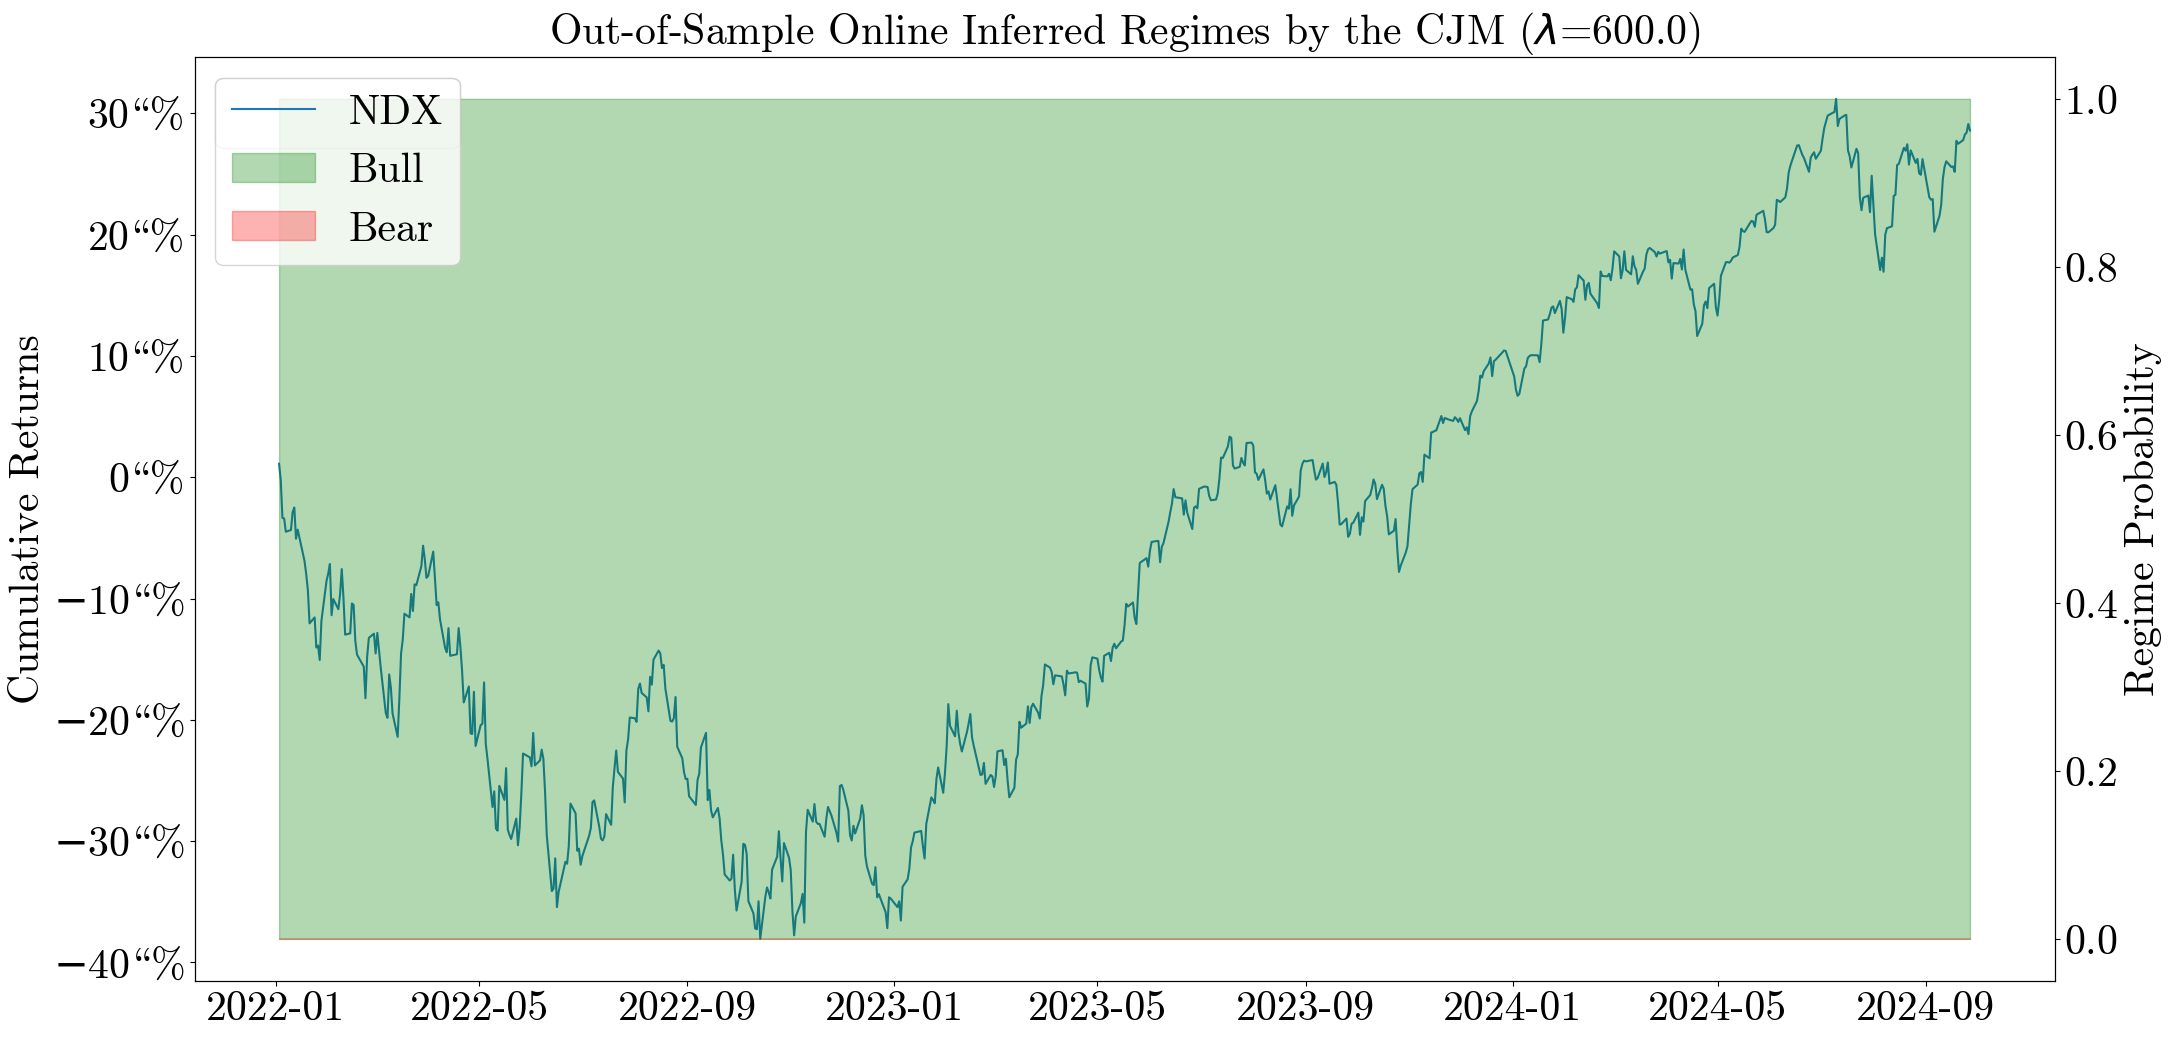

In [45]:
# online inference
proba_test_online = cjm.predict_proba_online(X_test_processed)

# plot
ax, ax2 = plot_regimes_and_cumret(proba_test_online, data.ret_ser, start_date=test_start, end_date=test_end, )
ax2.set(ylabel="Regime Probability")
ax.set(title=f"Out-of-Sample Online Inferred Regimes by the CJM ($\\lambda$={jump_penalty})")
savefig_plt(f"{get_curr_dir()}/plots/CJM_lambd-{jump_penalty}_test_online.pdf")

# SJM: Sparse JM with Feature Selection

Finally, the Sparse Jump Model (SJM) introduces feature weighting on top of the original JM or CJM. 
Features leading to better in-sample clustering effects, as measured by variance reduction, are assigned higher weights, while a LASSO-like constraint on the weight vector ensures that noisy features receive zero weight.

## In-Sample Fitting

### Parameters

SJM is implemented in the class `SparseJumpModel`, with an additional parameter `max_feats`, which controls the number of features included.
This parameter roughly reflects the effective number of features. (In the notation of Nystrup et al. (2021), `max_feats` corresponds to $\kappa^2$.)

The jump penalty value is of a similar magnitude to the non-sparse model. In this case, we try `max_feats=3.` and `jump_penalty=50.`

In [46]:
max_feats=5.
jump_penalty=50.
# init sjm instance
sjm = SparseJumpModel(n_components=2, max_feats=max_feats, jump_penalty=jump_penalty, )
# fit
sjm.fit(X_train_processed, ret_ser=data.ret_ser, sort_by="cumret")

AssertionError: 

The feature weights are stored in the attribute `feature_weights`. 
Generally, we observe that features with longer halflives receive higher weights, indicating that less smoothed features are noisier and are excluded from the model, thanks to the feature weighting mechanism.

In [ ]:
print("SJM Feature Weights:", "-"*50, sjm.feat_weights, sep="\n")

SJM Feature Weights:
--------------------------------------------------
ret_5         0.304149
DD-log_5      0.000000
sortino_5     0.244945
ret_20        0.666727
DD-log_20     0.000000
sortino_20    0.728562
ret_60        0.651968
DD-log_60     0.352528
sortino_60    0.747595
dtype: float64


A comparison of the SJM-identified regimes with those identified by JM reveals that the GFC is consolidated into a single bear regime, demonstrating that short-term noise has been effectively mitigated.

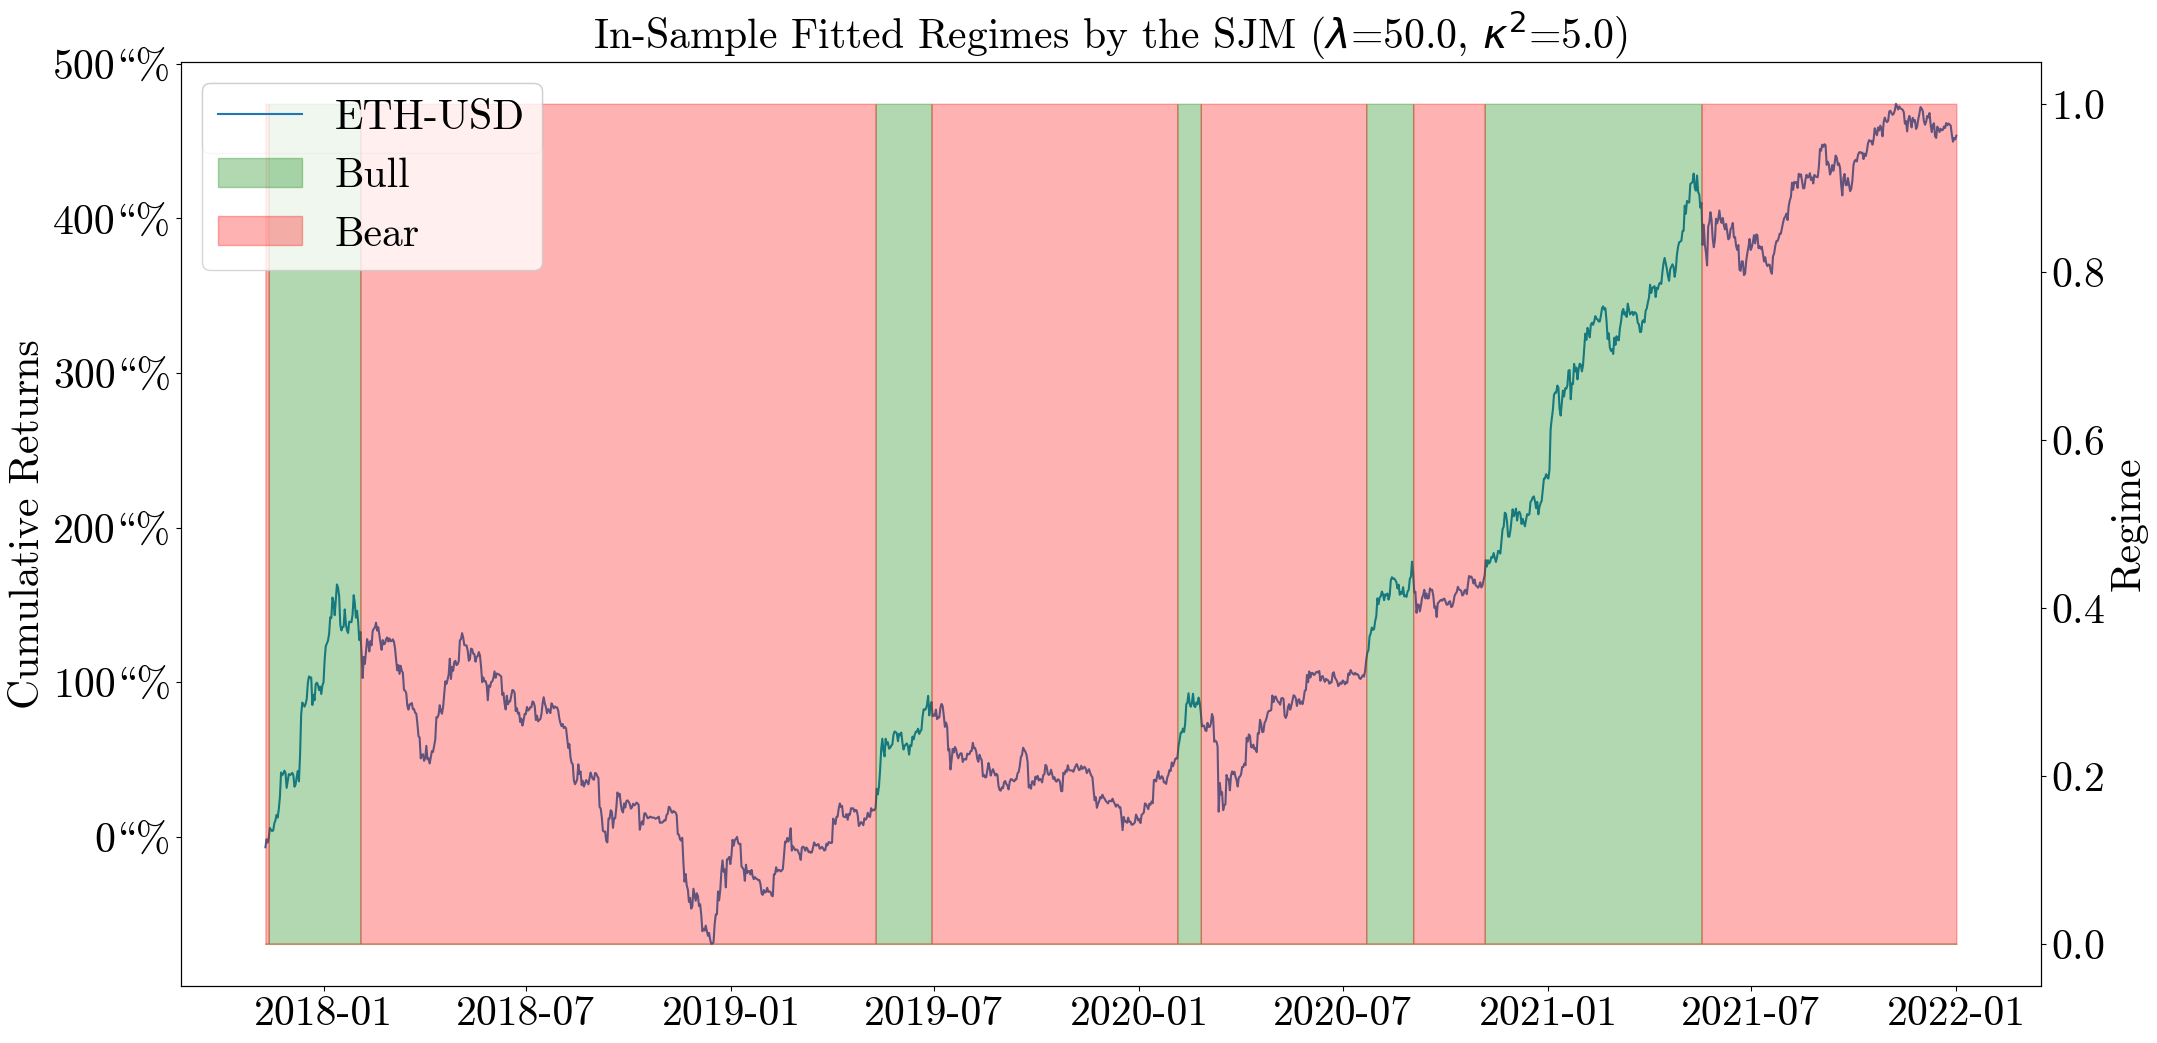

In [ ]:
# plot
ax, ax2 = plot_regimes_and_cumret(sjm.labels_, data.ret_ser, n_c=2, start_date=train_start, end_date=train_end, )
ax.set(title=f"In-Sample Fitted Regimes by the SJM ($\\lambda$={jump_penalty}, $\\kappa^2$={max_feats})")
savefig_plt(f"{get_curr_dir()}/plots/SJM_lambd-{jump_penalty}_max-feats-{max_feats}_train.pdf")

## Online Inference

As before, the `.predict_online()` method handles online inference. 
Notably, through feature selection, the previously problematic bear market signal in late 2024 is absent in the SJM's online inference, highlighting the potential benefits of feature selection.



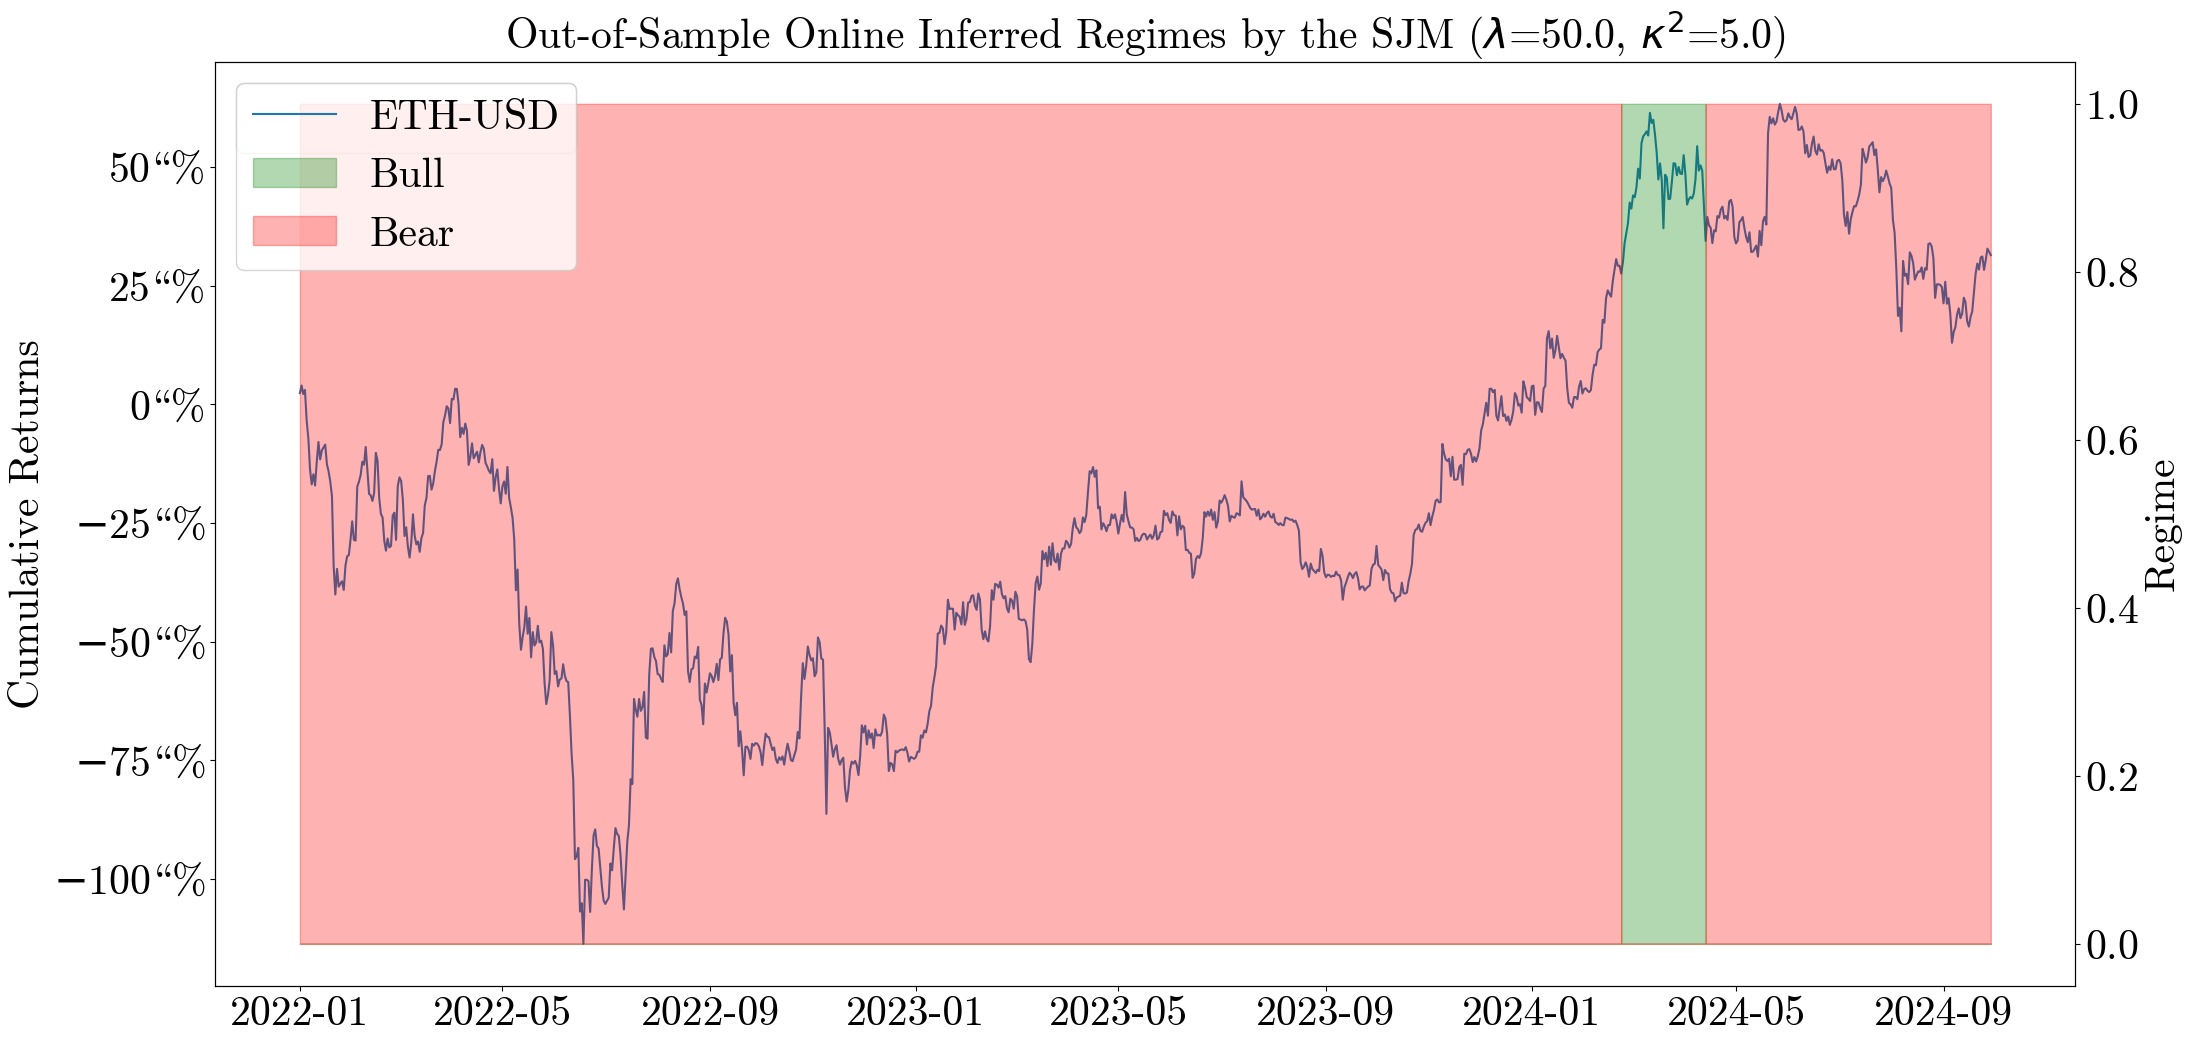

In [ ]:
# online inference
labels_test_online_sjm = sjm.predict_online(X_test_processed)

# plot
ax, ax2 = plot_regimes_and_cumret(labels_test_online_sjm, data.ret_ser, start_date=test_start, end_date=test_end, )
ax.set(title=f"Out-of-Sample Online Inferred Regimes by the SJM ($\\lambda$={jump_penalty}, $\\kappa^2$={max_feats})")
savefig_plt(f"{get_curr_dir()}/plots/SJM_lambd-{jump_penalty}_max-feats-{max_feats}_test_online.pdf")

# Conclusion

This concludes the introduction to the functionalities of our `jumpmodels` library. 
The field of statistical jump models is still actively evolving, with ongoing research exploring new avenues.
We hope that the models and helper functions provided in this package will be useful in your own work. 
Citations and credits are always appreciated.

We welcome pull requests and open issues, and I’m happy to discuss any related questions.